In [4]:
# STEP 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score


In [5]:
# STEP 2: Load and explore data
data = pd.read_csv(r"C:\Users\HI\OneDrive\Desktop\Project-2\human detection.csv")
print("Data shape:", data.shape)
print("\nFirst 3 rows:")
print(data.head(3))

Data shape: (10299, 563)

First 3 rows:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.257178          -0.023285          -0.014654         -0.938404   
1           0.286027          -0.013163          -0.119083         -0.975415   
2           0.275485          -0.026050          -0.118152         -0.993819   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.920091         -0.667683         -0.952501         -0.925249   
1         -0.967458         -0.944958         -0.986799         -0.968401   
2         -0.969926         -0.962748         -0.994403         -0.970735   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyroJerkMag-kurtosis()  \
0         -0.674302         -0.894088  ...                        -0.705974   
1         -0.945823         -0.894088  ...                        -0.594944   
2         -0.963483         -0.939260  ...                        -0.640736   

   angle(tBod

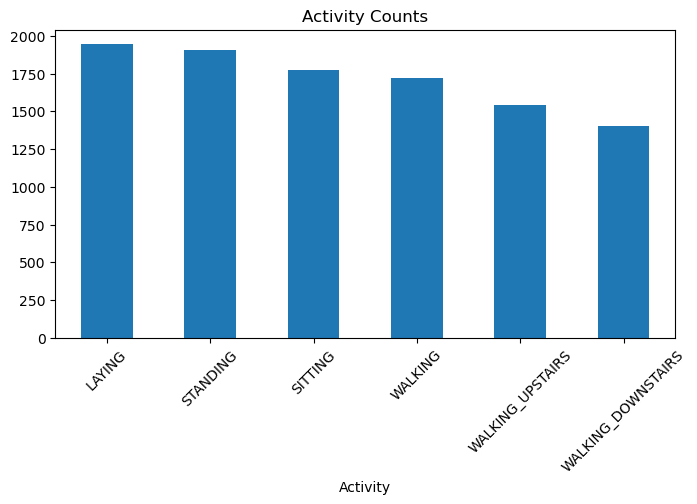

In [6]:
# Activity distribution
plt.figure(figsize=(8,4))
data['Activity'].value_counts().plot(kind='bar')
plt.title('Activity Counts')
plt.xticks(rotation=45)
plt.show()

In [7]:
# STEP 3: Prepare data
X = data.drop(['subject', 'Activity'], axis=1)
y = data['Activity']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
# STEP 4: Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       369
           SITTING       0.96      0.96      0.96       355
          STANDING       0.96      0.96      0.96       363
           WALKING       1.00      0.98      0.99       396
WALKING_DOWNSTAIRS       0.97      0.98      0.98       261
  WALKING_UPSTAIRS       0.98      0.99      0.98       316

          accuracy                           0.98      2060
         macro avg       0.98      0.98      0.98      2060
      weighted avg       0.98      0.98      0.98      2060



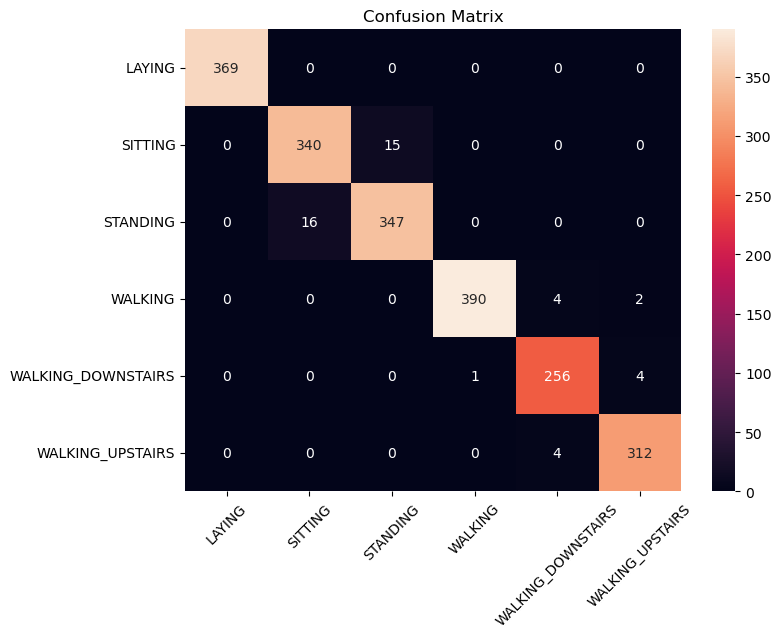


Final Model Accuracy: 97.77%


In [10]:
# STEP 5: Evaluate model
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.show()
print(f"\nFinal Model Accuracy: {accuracy * 100:.2f}%")

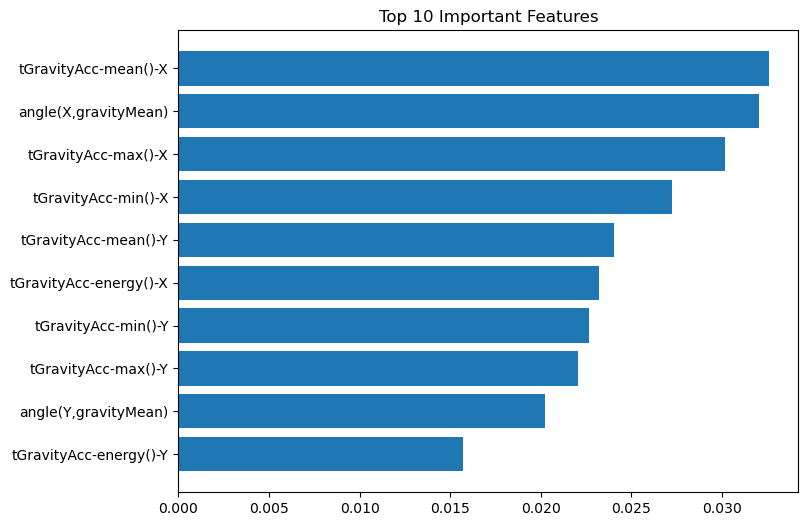

In [11]:
# STEP 6: Feature importance
importances = model.feature_importances_
top_features = 10  # Show top 10 features
indices = np.argsort(importances)[-top_features:]

plt.figure(figsize=(8,6))
plt.barh(range(top_features), importances[indices])
plt.yticks(range(top_features), X.columns[indices])
plt.title('Top 10 Important Features')
plt.show()

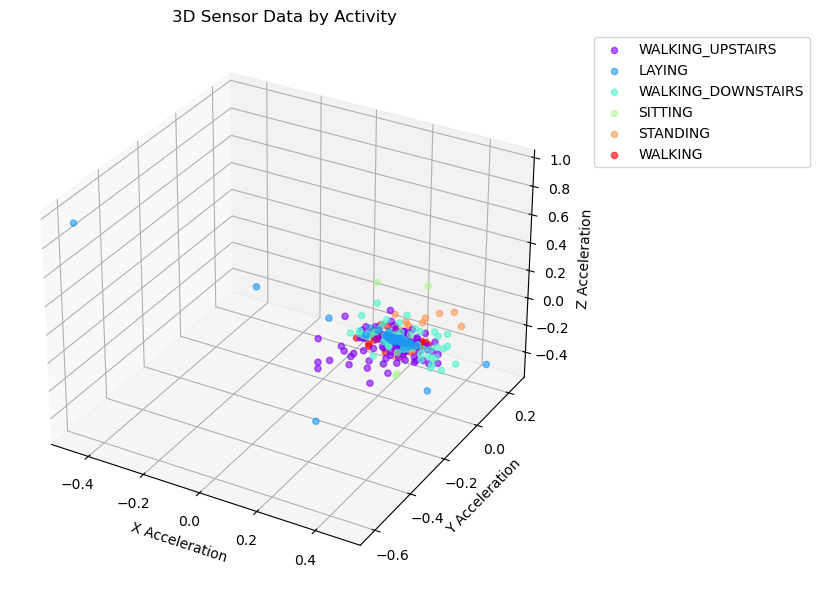


Final Model Accuracy: 97.77%


In [12]:
# STEP 7: Sensor data visualization (3D plot)
plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')

sample = data.sample(500)  # Take a sample for visualization
activities = sample['Activity'].unique()

# Assign colors to activities
colors = plt.cm.rainbow(np.linspace(0, 1, len(activities)))
activity_color = {act:color for act, color in zip(activities, colors)}

for activity in activities:
    subset = sample[sample['Activity'] == activity]
    ax.scatter3D(subset['tBodyAcc-mean()-X'],
                subset['tBodyAcc-mean()-Y'],
                subset['tBodyAcc-mean()-Z'],
                color=activity_color[activity],
                label=activity,
                alpha=0.6)

ax.set_xlabel('X Acceleration')
ax.set_ylabel('Y Acceleration')
ax.set_zlabel('Z Acceleration')
ax.set_title('3D Sensor Data by Activity')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# FINAL STEP: Print Accuracy
print(f"\nFinal Model Accuracy: {accuracy * 100:.2f}%")


In [13]:
#  FINAL STEP: Highlight Accuracy Again at End
final_accuracy = accuracy_score(y_test, y_pred)
print("\n Final Accuracy of Random Forest Model: {:.2f}%".format(final_accuracy * 100))


 Final Accuracy of Random Forest Model: 97.77%


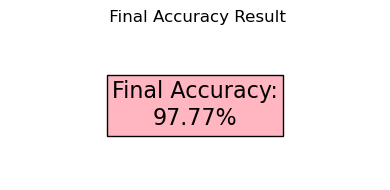

In [14]:
#  Accuracy as a visual box
plt.figure(figsize=(4, 2))
plt.text(0.5, 0.5, f"Final Accuracy:\n{final_accuracy * 100:.2f}%",
         fontsize=16, ha='center', va='center',
         bbox=dict(facecolor='lightpink', edgecolor='black'))
plt.axis('off')
plt.title(" Final Accuracy Result")
plt.tight_layout()
plt.show()